In [2]:
import numpy as np
from matplotlib import pyplot as plt
import sympy as sp

In [3]:
 # Symbols
x, y, Y, ni, E = sp.symbols('x y Y ni E', real=True)
pi = sp.pi

In [10]:
# ----------------------------
# First set
# ----------------------------
ex = (2 * Y * y * (ni * y**2 - x**2)) / (E * pi * (x**2 + y**2)**2)
ey = (2 * Y * y * (ni * x**2 - y**2)) / (E * pi * (x**2 + y**2)**2)
exy = -(2 * Y * x * y**2 * (ni + 1)) / (E * pi * (x**2 + y**2)**2)

compEqS = sp.simplify(
    sp.diff(ex, y, 2) +
    sp.diff(ey, x, 2) -
    2 * sp.diff(sp.diff(exy, x), y)
)

print("ex =")
sp.pprint(ex)
print("\ney =")
sp.pprint(ey)
print("\nexy =")
sp.pprint(exy)


ex =
      ⎛    2    2⎞
2⋅Y⋅y⋅⎝ni⋅y  - x ⎠
──────────────────
               2  
      ⎛ 2    2⎞   
  π⋅E⋅⎝x  + y ⎠   

ey =
      ⎛    2    2⎞
2⋅Y⋅y⋅⎝ni⋅x  - y ⎠
──────────────────
               2  
      ⎛ 2    2⎞   
  π⋅E⋅⎝x  + y ⎠   

exy =
        2          
-2⋅Y⋅x⋅y ⋅(ni + 1) 
───────────────────
               2   
      ⎛ 2    2⎞    
  π⋅E⋅⎝x  + y ⎠    


In [11]:
print("\ncompEqS =")
sp.pprint(compEqS)


compEqS =
0


In [9]:
# ----------------------------
# Second set
# ----------------------------
ex_2 = (2 * Y * y * (ni * y**2 - x**2)) / (E * pi * (x**2 + y**2)**2)
ey_2 = (2 * Y * y * (ni * x**2 - y**2)) / (E * pi * (x**2 + y**2)**2)
exy_2 = -(2 * Y * (y**3 + x * y**2) * (ni + 1)) / (E * pi * (x**2 + y**2)**2)

compEqS2 = sp.simplify(
    sp.diff(ex_2, y, 2) +
    sp.diff(ey_2, x, 2) -
    2 * sp.diff(sp.diff(exy_2, x), y)
)

print("\ncompEqS2 =")
sp.pprint(compEqS2)


compEqS2 =
           2 ⎛      2       2    2    2⎞   
   48⋅Y⋅x⋅y ⋅⎝- ni⋅x  + ni⋅y  - x  + y ⎠   
───────────────────────────────────────────
    ⎛ 8      6  2      4  4      2  6    8⎞
π⋅E⋅⎝x  + 4⋅x ⋅y  + 6⋅x ⋅y  + 4⋅x ⋅y  + y ⎠


In [12]:
# ----------------------------
# Displacements u, v
# ----------------------------
u = Y * E**(-1) * (
    (1 - ni) * (sp.atan(y / x) / pi - sp.Rational(1, 2)) +
    (1 + ni) * x * y / (pi * (x**2 + y**2))
)

v = -Y * (
    2 * sp.log((x**2 + y**2)**sp.Rational(1, 2)) +
    (1 + ni) * x**2 / (x**2 + y**2)
) / (pi * E)

In [13]:
exC = sp.simplify(sp.diff(u, x))
eyC = sp.simplify(sp.diff(v, y))
exyC = sp.simplify((sp.diff(u, y) + sp.diff(v, x)) / 2)


In [14]:
print("\nu =")
sp.pprint(u)
print("\nv =")
sp.pprint(v)
print("\nexC =")
sp.pprint(exC)
print("\neyC =")
sp.pprint(eyC)
print("\nexyC =")
sp.pprint(exyC)


u =
  ⎛                        ⎛    ⎛y⎞    ⎞⎞
  ⎜                        ⎜atan⎜─⎟    ⎟⎟
  ⎜x⋅y⋅(ni + 1)            ⎜    ⎝x⎠   1⎟⎟
Y⋅⎜──────────── + (1 - ni)⋅⎜─────── - ─⎟⎟
  ⎜  ⎛ 2    2⎞             ⎝   π      2⎠⎟
  ⎝π⋅⎝x  + y ⎠                          ⎠
─────────────────────────────────────────
                    E                    

v =
   ⎛ 2                 ⎛   _________⎞⎞ 
   ⎜x ⋅(ni + 1)        ⎜  ╱  2    2 ⎟⎟ 
-Y⋅⎜─────────── + 2⋅log⎝╲╱  x  + y  ⎠⎟ 
   ⎜   2    2                        ⎟ 
   ⎝  x  + y                         ⎠ 
───────────────────────────────────────
                  π⋅E                  

exC =
        ⎛    2    2⎞   
  2⋅Y⋅y⋅⎝ni⋅y  - x ⎠   
───────────────────────
    ⎛ 4      2  2    4⎞
π⋅E⋅⎝x  + 2⋅x ⋅y  + y ⎠

eyC =
      ⎛ 2             2    2⎞
2⋅Y⋅y⋅⎝x ⋅(ni + 1) - x  - y ⎠
─────────────────────────────
                    2        
           ⎛ 2    2⎞         
       π⋅E⋅⎝x  + y ⎠         

exyC =
         2             
  2⋅Y⋅x⋅y ⋅(-ni - 1)   
────

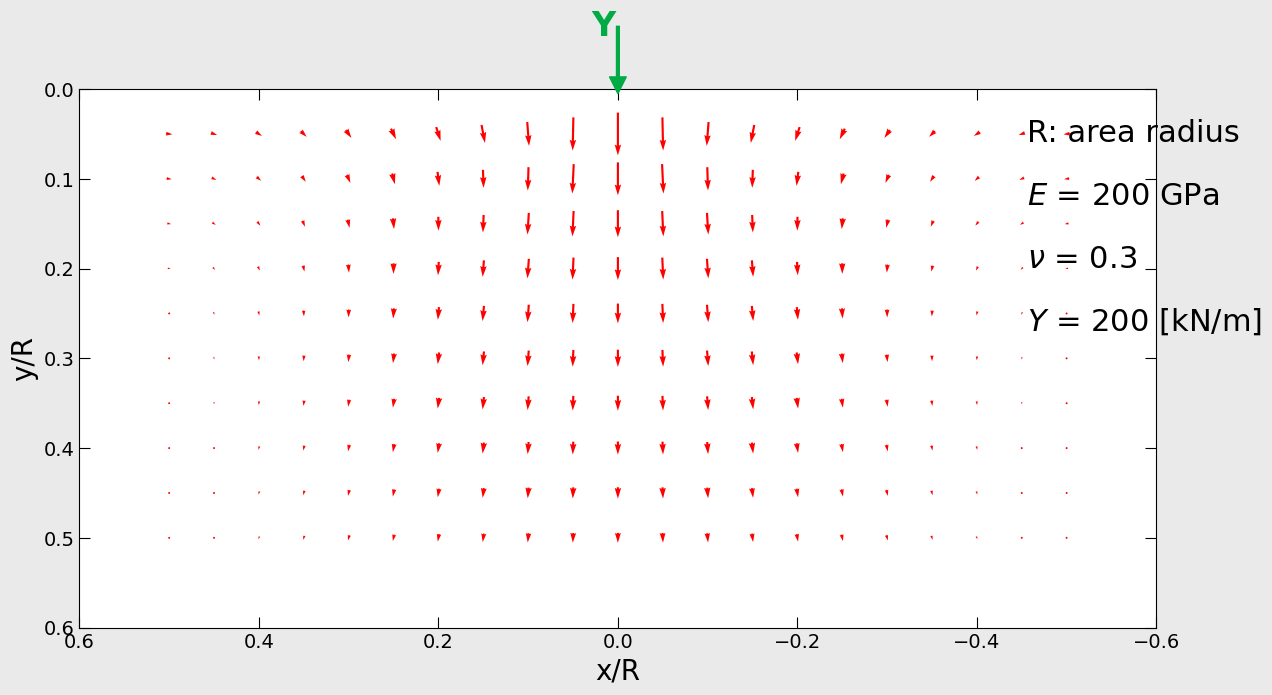

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Material / load parameters
# ----------------------------
E = 200e9      # Young modulus [Pa]
nu = 0.3       # Poisson ratio
Y = 200e3      # load [N/m]  (200 kN/m)

# ----------------------------
# Grid (normalized coordinates)
# ----------------------------
x_vals = np.arange(-0.5, 0.5 + 0.05, 0.05)
y_vals = np.arange(0.05, 0.5 + 0.05, 0.05)

xlt, ylt = np.meshgrid(x_vals, y_vals)

# ----------------------------
# Flamant displacement field
# ----------------------------
r2 = xlt**2 + ylt**2
r = np.sqrt(r2)

uxlt = (Y / E) * (
    (1 - nu) * (np.arctan2(ylt, xlt) / np.pi - 0.5)
    + (1 + nu) * xlt * ylt / (np.pi * r2)
)

uylt = -(Y / (np.pi * E)) * (
    2 * np.log(r)
    + (1 + nu) * xlt**2 / r2
)

# ----------------------------
# Artificial scaling (for visualization only)
# ----------------------------
scale_vis = 5e4

ux_plot = scale_vis * uxlt
uy_plot = scale_vis * uylt

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 7))

fig.patch.set_facecolor('#eaeaea')
ax.set_facecolor('white')

ax.quiver(
    xlt, ylt,
    ux_plot, uy_plot,
    color='red',
    angles='xy',
    scale_units='xy',
    scale=2,
    width=0.002,
    pivot='middle'
)

# Reverse axes to match MATLAB-style half-space visualization
ax.invert_xaxis()
ax.invert_yaxis()

ax.set_aspect('equal')

ax.set_xlim(0.6, -0.6)
ax.set_ylim(0.6, 0.0)

ax.set_xlabel('x/R', fontsize=20)
ax.set_ylabel('y/R', fontsize=20)

ax.tick_params(direction='in', top=True, right=True, length=8, labelsize=14)

# ----------------------------
# Load arrow
# ----------------------------
ax.annotate(
    '',
    xy=(0.0, 0.005),
    xytext=(0.0, -0.07),
    arrowprops=dict(
        facecolor='#00aa44',
        edgecolor='#00aa44',
        width=2,
        headwidth=12,
        headlength=12
    )
)

ax.text(
    0.03,
    -0.07,
    'Y',
    color='#00aa44',
    fontsize=24,
    fontweight='bold',
    va='center'
)

# ----------------------------
# Right-side annotations
# ----------------------------
fig.text(0.86, 0.80, 'R: area radius', fontsize=22)
fig.text(0.86, 0.71, r'$E$ = 200 GPa', fontsize=22)
fig.text(0.86, 0.62, r'$\nu$ = 0.3', fontsize=22)
fig.text(0.86, 0.53, r'$Y$ = 200 [kN/m]', fontsize=22)

plt.tight_layout()
plt.show()

<h1>My example:

In [34]:
# ============================================================
# 1. SYMBOLIC PART
#    Check compatibility + verify displacement -> strain field
# ============================================================

# Symbols
x, y, X, nu, E = sp.symbols('x y X nu E', real=True)
pi = sp.pi

# ------------------------------------------------------------
# Candidate strain field 1
# ------------------------------------------------------------
ex1 = (2 * X * x * (nu * y**2 - x**2)) / (E * pi * (x**2 + y**2)**2)
ey1 = (2 * X * x * (nu * x**2 - y**2)) / (E * pi * (x**2 + y**2)**2)
exy1 = -(4 * X * x**2 * y * (nu + 1)) / (E * pi * (x**2 + y**2)**2)

comp1 = sp.simplify(
    sp.diff(ex1, y, 2) +
    sp.diff(ey1, x, 2) -
    2 * sp.diff(sp.diff(exy1, x), y)
)



In [35]:
# ------------------------------------------------------------
# Candidate strain field 2
# ------------------------------------------------------------
ex2 = (2 * X * x * (nu * y**2 - x**2)) / (E * pi * (x**2 + y**2)**2)
ey2 = (2 * X * x * (nu * x**2 - y**2)) / (E * pi * (x**2 + y**2)**2)
exy2 = -(2 * X * x**2 * y * (nu + 1)) / (E * pi * (x**2 + y**2)**2)

comp2 = sp.simplify(
    sp.diff(ex2, y, 2) +
    sp.diff(ey2, x, 2) -
    2 * sp.diff(sp.diff(exy2, x), y)
)



In [36]:
# ------------------------------------------------------------
# Given displacement field from your sheet
# u = horizontal displacement
# v = vertical displacement
# ------------------------------------------------------------
u_disp = -X * (
    2 * sp.log(sp.sqrt(x**2 + y**2)) +
    y**2 * (nu + 1) / (x**2 + y**2)
) / (E * pi)

v_disp = (X / E) * (
    ((sp.atan(y / x) / pi) - sp.Rational(1, 2)) * (nu - 1) +
    x * y * (nu + 1) / (pi * (x**2 + y**2))
)

# ------------------------------------------------------------
# Strains computed from displacements
# Tensorial shear strain:
# exy = (du/dy + dv/dx)/2
# ------------------------------------------------------------
ex_from_u = sp.simplify(sp.diff(u_disp, x))
ey_from_v = sp.simplify(sp.diff(v_disp, y))
exy_from_uv = sp.simplify((sp.diff(u_disp, y) + sp.diff(v_disp, x)) / 2)

# ------------------------------------------------------------
# Compare displacement-derived strains with both candidates
# ------------------------------------------------------------
diff_ex_1 = sp.simplify(ex_from_u - ex1)
diff_ey_1 = sp.simplify(ey_from_v - ey1)
diff_exy_1 = sp.simplify(exy_from_uv - exy1)

diff_ex_2 = sp.simplify(ex_from_u - ex2)
diff_ey_2 = sp.simplify(ey_from_v - ey2)
diff_exy_2 = sp.simplify(exy_from_uv - exy2)

# ============================================================
# 2. PRINT RESULTS
# ============================================================

print("\n" + "=" * 70)
print("COMPATIBILITY CHECK")
print("=" * 70)
print("Compatibility of field 1:")
sp.pprint(comp1)

print("\nCompatibility of field 2:")
sp.pprint(comp2)

print("\n" + "=" * 70)
print("STRAINS FROM DISPLACEMENT FIELD")
print("=" * 70)
print("epsilon_xx from displacement:")
sp.pprint(ex_from_u)

print("\nepsilon_yy from displacement:")
sp.pprint(ey_from_v)

print("\nepsilon_xy from displacement:")
sp.pprint(exy_from_uv)

print("\n" + "=" * 70)
print("COMPARE WITH CANDIDATE FIELD 1")
print("=" * 70)
print("ex_from_u - ex1 =")
sp.pprint(diff_ex_1)
print("\ney_from_v - ey1 =")
sp.pprint(diff_ey_1)
print("\nexy_from_uv - exy1 =")
sp.pprint(diff_exy_1)

print("\n" + "=" * 70)
print("COMPARE WITH CANDIDATE FIELD 2")
print("=" * 70)
print("ex_from_u - ex2 =")
sp.pprint(diff_ex_2)
print("\ney_from_v - ey2 =")
sp.pprint(diff_ey_2)
print("\nexy_from_uv - exy2 =")
sp.pprint(diff_exy_2)

# Optional boolean check
field1_matches = (
    diff_ex_1 == 0 and
    diff_ey_1 == 0 and
    diff_exy_1 == 0
)

field2_matches = (
    diff_ex_2 == 0 and
    diff_ey_2 == 0 and
    diff_exy_2 == 0
)

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Field 1 compatibility satisfied?  {comp1 == 0}")
print(f"Field 2 compatibility satisfied?  {comp2 == 0}")
print(f"Displacement field matches field 1? {field1_matches}")
print(f"Displacement field matches field 2? {field2_matches}")




COMPATIBILITY CHECK
Compatibility of field 1:
      ⎛     4        2  2        4    4      2  2      4⎞
8⋅X⋅x⋅⎝- ν⋅x  + 8⋅ν⋅x ⋅y  - 3⋅ν⋅y  - x  + 8⋅x ⋅y  - 3⋅y ⎠
─────────────────────────────────────────────────────────
           ⎛ 8      6  2      4  4      2  6    8⎞       
       π⋅E⋅⎝x  + 4⋅x ⋅y  + 6⋅x ⋅y  + 4⋅x ⋅y  + y ⎠       

Compatibility of field 2:
0

STRAINS FROM DISPLACEMENT FIELD
epsilon_xx from displacement:
      ⎛   2    2            2⎞
2⋅X⋅x⋅⎝- x  + y ⋅(ν + 1) - y ⎠
──────────────────────────────
                     2        
            ⎛ 2    2⎞         
        π⋅E⋅⎝x  + y ⎠         

epsilon_yy from displacement:
      ⎛  ⎛ 2    2⎞    2        ⎞
2⋅X⋅x⋅⎝ν⋅⎝x  + y ⎠ - y ⋅(ν + 1)⎠
────────────────────────────────
                      2         
             ⎛ 2    2⎞          
         π⋅E⋅⎝x  + y ⎠          

epsilon_xy from displacement:
        2              
   2⋅X⋅x ⋅y⋅(-ν - 1)   
───────────────────────
    ⎛ 4      2  2    4⎞
π⋅E⋅⎝x  + 2⋅x ⋅y  + y ⎠

COMP

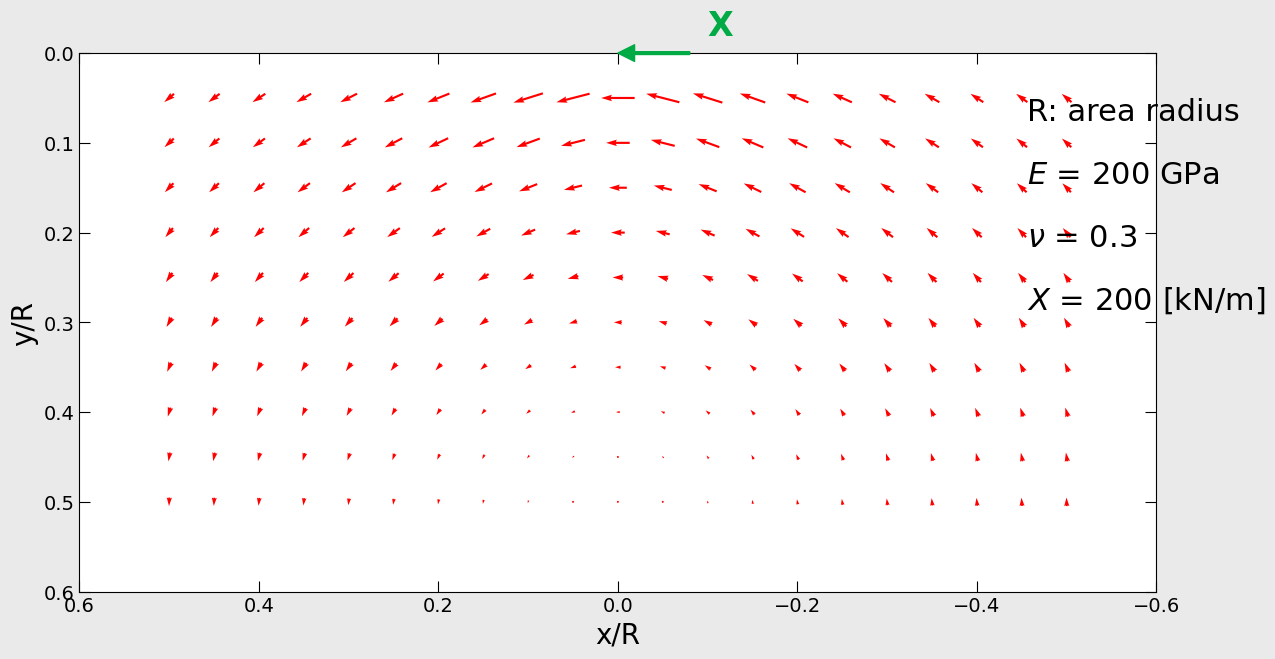

In [38]:
# ============================================================
# 3. NUMERICAL VISUALIZATION OF DISPLACEMENT FIELD
#    Same style as before, but now for horizontal force X
# ============================================================

# Material / load values
E_val = 200e9     # Pa
nu_val = 0.3
X_val = 200e3     # N/m

# Grid in normalized coordinates
# We avoid y=0 because the solution is singular at the load point
x_vals = np.arange(-0.5, 0.5 + 0.05, 0.05)
y_vals = np.arange(0.05, 0.5 + 0.05, 0.05)
xlt, ylt = np.meshgrid(x_vals, y_vals)

r2 = xlt**2 + ylt**2
r = np.sqrt(r2)

# Numerical displacement field
# IMPORTANT:
# use arctan2(y, x) in numeric evaluation
ux = -(X_val / (E_val * np.pi)) * (
    2 * np.log(r) +
    ylt**2 * (nu_val + 1) / r2
)

uy = (X_val / E_val) * (
    (np.arctan2(ylt, xlt) / np.pi - 0.5) * (nu_val - 1) +
    xlt * ylt * (nu_val + 1) / (np.pi * r2)
)

# Artificial scaling only for visualization
scale_vis = 5e4
ux_plot = scale_vis * ux
uy_plot = scale_vis * uy

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#eaeaea')
ax.set_facecolor('white')

ax.quiver(
    xlt, ylt,
    ux_plot, uy_plot,
    color='red',
    angles='xy',
    scale_units='xy',
    scale=2,
    width=0.002,
    pivot='middle'
)

# Reverse axes to keep the same style as your previous plot
# and to mimic the half-space engineering view
ax.invert_xaxis()
ax.invert_yaxis()

ax.set_aspect('equal')
ax.set_xlim(0.6, -0.6)
ax.set_ylim(0.6, 0.0)

ax.set_xlabel('x/R', fontsize=20)
ax.set_ylabel('y/R', fontsize=20)
ax.tick_params(direction='in', top=True, right=True, length=8, labelsize=14)

# Horizontal load arrow at the surface
ax.annotate(
    '',
    xy=(0.0, 0.0),
    xytext=(-0.08, 0.0),
    arrowprops=dict(
        facecolor='#00aa44',
        edgecolor='#00aa44',
        width=2,
        headwidth=12,
        headlength=12
    )
)

ax.text(
    -0.10, -0.02,
    'X',
    color='#00aa44',
    fontsize=24,
    fontweight='bold'
)

# Right-side annotations
fig.text(0.86, 0.80, 'R: area radius', fontsize=22)
fig.text(0.86, 0.71, r'$E$ = 200 GPa', fontsize=22)
fig.text(0.86, 0.62, r'$\nu$ = 0.3', fontsize=22)
fig.text(0.86, 0.53, r'$X$ = 200 [kN/m]', fontsize=22)

plt.tight_layout()
plt.show()